In [1]:
from pyrokinetics import Pyro
from pathlib import Path
import os
import numpy as np
import copy
import scipy

In [2]:
GYRO_DATA = Path("/mnt/data/Gyrokinetic_Simulations")

In [3]:
gs2_mtm_file = "/mnt/data/Downloads/zenodo/linear/gs2/coll/nue030_fbpar1/n25/input.in"

gs2_pyro = Pyro(gk_file = gs2_mtm_file)
gs2_pyro.load_gk_output()

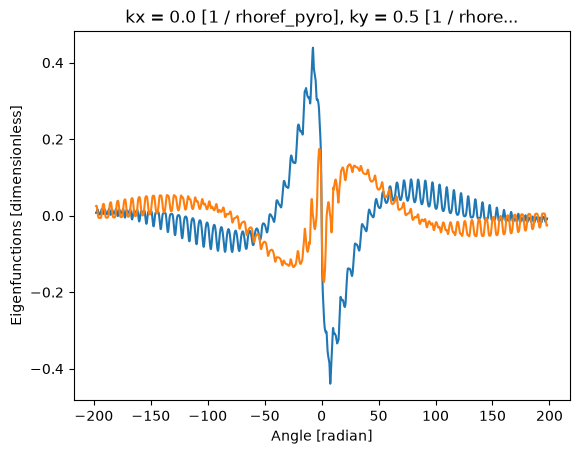

In [4]:
np.real(gs2_pyro.gk_output["eigenfunctions"].isel(kx = 0).isel(ky = 0).sel(field = "phi")).plot()
np.imag(gs2_pyro.gk_output["eigenfunctions"].isel(kx = 0).isel(ky = 0).sel(field = "phi")).plot()

In [5]:
GFTM_pyro = copy.copy(gs2_pyro)
GFTM_pyro.gk_code = "GFTM"

/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/pyrokinetics/src/pyrokinetics/pyro.py:346: UserWarning: Setting gk_code to GFTM without first reading a gyrokinetics file of that type. Creating a new context using the default template file for GFTM and data from the previous context (if available).
  warnings.warn(warn_msg, UserWarning)


In [6]:
max_theta =(2*gs2_pyro.numerics["nperiod"]-1)*np.pi

In [7]:
np.pi * 2 - max_theta

-191.63715186897738

In [8]:
GFTM_pyro.gk_input.data["nxgrid"]

32

In [36]:
radial_extent = 9 * np.pi
nabsis = 32
nxgrid_number = nabsis + 1
roots = scipy.special.roots_hermite(nxgrid_number)
print(max_theta/roots[0][-1])

27.284860792920433


In [26]:
#generate roots of hermitian basis functions
nabsis = 32
nxgrid_numerb = nabsis + 1
roots = scipy.special.roots_hermite(nxgrid_numerb)

GFTM_pyro.gk_input.data["nbasis_max"] = nabsis
GFTM_pyro.gk_input.data["nxgrid"] = nxgrid_numerb

from scipy.special import eval_hermite
eval_hermite(nxgrid_numerb , roots[0])


array([ 9.36907739e+19, -1.15890849e+18, -1.75000574e+16, -1.76479276e+14,
        9.64256557e+13,  1.43509366e+11,  1.09724758e+12, -9.12371746e+10,
       -3.56350784e+10,  3.98013151e+09, -4.21146554e+08, -4.86394611e+08,
       -1.06769549e+08, -9.49062656e+07, -1.18632832e+07,  2.37265664e+07,
        0.00000000e+00, -2.37265664e+07,  1.18632832e+07,  9.49062656e+07,
        1.06769549e+08,  4.86394611e+08,  4.21146554e+08, -3.98013151e+09,
        3.56350784e+10,  9.12371746e+10, -1.09724758e+12, -1.43509366e+11,
       -9.64256557e+13,  1.76479276e+14,  1.75000574e+16,  1.15890849e+18,
       -9.36907739e+19])

In [27]:
ideal_width = max_theta/roots[0][-1]

In [28]:
GFTM_pyro.gk_input.data["width"] = ideal_width

In [29]:
ideal_width

np.float64(27.284860792920433)

In [30]:
output_location = GYRO_DATA / "GFTM" / "Runs" / "MTM_TEST" / f"width_{ideal_width:.3g}" / "input.gftm"
GFTM_pyro.write_gk_file(file_name=output_location)

In [31]:
GFTM_pyro.load_gk_output()

/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/pyrokinetics/src/pyrokinetics/gk_code/gftm.py:1251: RuntimeWarning: invalid value encountered in scalar divide
  phase = np.abs(phi_theta_star) / phi_theta_star
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/pint/facets/plain/quantity.py:984: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(self._magnitude, other_magnitude)


In [32]:
GFTM_pyro.gk_output

<pyrokinetics.GKOutput>
(Wraps <xarray.Dataset>) Size: 33kB
Dimensions:                (ky: 1, mode: 2, field: 3, theta: 289, time: 1,
                            kx: 1, species: 2)
Coordinates:
  * time                   (time) float64 8B 0.0
  * kx                     (kx) float64 8B 0.0
  * ky                     (ky) float64 8B 0.5
  * theta                  (theta) float64 2kB -28.27 -28.1 ... 28.1 28.27
  * mode                   (mode) int64 16B 0 1
  * species                (species) <U8 64B 'electron' 'ion1'
  * field                  (field) <U4 48B 'phi' 'apar' 'bpar'
Data variables:
    growth_rate            (ky, mode) float64 16B [vref_nrl/lref_minor_radius] ...
    mode_frequency         (ky, mode) float64 16B [vref_nrl/lref_minor_radius] ...
    eigenvalues            (ky, mode) complex128 32B [vref_nrl/lref_minor_radius] ...
    eigenfunctions         (field, theta, mode) complex128 28kB [] (nan+nanj)...
    jacobian               (theta) float64 2kB [lref_minor_radiu

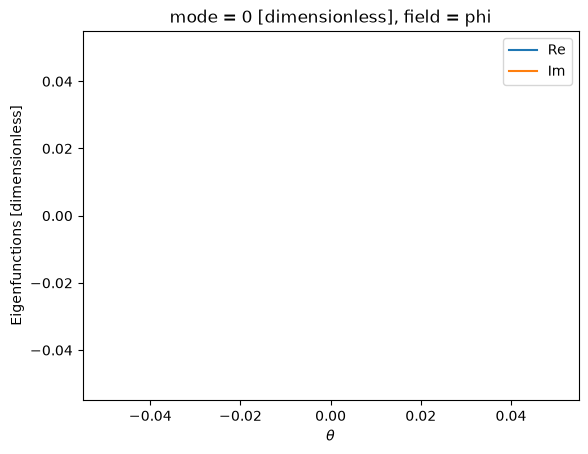

In [34]:
import matplotlib.pyplot as plt

phi = GFTM_pyro.gk_output["eigenfunctions"].isel(mode=0).sel(field="phi")

fig, ax = plt.subplots()
np.real(phi).plot(ax=ax, x="theta", label="Re")
np.imag(phi).plot(ax=ax, x="theta", label="Im")
#ax.set_xlim(-max_theta, max_theta)
ax.set_xlabel(r"$\theta$")
ax.legend()